# LightGBM Churn Prediction Model
## HPB Fintech Hackathon 2026

### Pipeline
1. Load cleaned features (single period, 10 features)
2. **Stratified train/test split** (80/20) for honest evaluation
3. **SMOTE oversampling** on training set to handle class imbalance
4. **Optuna hyperparameter tuning** — optimizing F1 via 5-fold stratified CV
5. Train final LightGBM with best parameters
6. Calibrate probabilities (Platt scaling) and **scale to 0–1** for intuitive risk scores
7. Optimize classification threshold for **F1 score**
8. Evaluate with confusion matrix, ROC, PR curves
9. **SHAP** feature importance for model interpretability
10. Generate per-customer churn risk scores

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

PROCESSED = Path('../data/processed')
OUTPUT = Path('../data/output')
df = pd.read_csv(PROCESSED / 'churn_features_clean.csv')

META_COLS = ['client_id', 'churned']
FEATURES = [c for c in df.columns if c not in META_COLS]
TARGET = 'churned'

X = df[FEATURES]
y = df[TARGET]

print(f'Dataset: {len(df):,} samples, {len(FEATURES)} features')
print(f'Churn rate: {y.mean():.1%} ({y.sum()} churned / {len(y)} total)')
print(f'Features: {FEATURES}')

/home/mmestrov/Desktop/natjecanja/fintech-hackathon/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset: 7,805 samples, 10 features
Churn rate: 1.7% (131 churned / 7805 total)
Features: ['tenure_years', 'n_products', 'has_loan', 'receives_salary', 'avg_txn_per_month', 'avg_txn_amount', 'txn_trend', 'avg_balance', 'balance_trend', 'n_contacts']


In [2]:
# ── Stratified Train/Test Split (80/20) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train: {len(X_train):,} samples, {y_train.sum()} churned ({y_train.mean():.1%})')
print(f'Test:  {len(X_test):,} samples, {y_test.sum()} churned ({y_test.mean():.1%})')

# ── SMOTE oversampling on training data only ──
smote = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f'\nAfter SMOTE: {len(X_train_sm):,} samples, {y_train_sm.sum()} churned ({y_train_sm.mean():.1%})')

# ── Optuna Hyperparameter Tuning ──
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'boosting_type': 'gbdt',
        'n_estimators': 500,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'num_leaves': trial.suggest_int('num_leaves', 8, 64),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 15.0),
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1,
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        sm = SMOTE(random_state=42, sampling_strategy=0.3)
        X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

        m = lgb.LGBMClassifier(**params)
        m.fit(X_tr_sm, y_tr_sm,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])

        proba = m.predict_proba(X_val)[:, 1]
        best_f1 = 0
        for t in np.arange(0.05, 0.95, 0.02):
            f1 = f1_score(y_val, (proba >= t).astype(int), zero_division=0)
            best_f1 = max(best_f1, f1)
        f1_scores.append(best_f1)

    return np.mean(f1_scores)

print('Running Optuna hyperparameter search (100 trials)...')
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'\nBest CV F1: {study.best_value:.4f}')
print(f'Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

Train: 6,244 samples, 105 churned (1.7%)
Test:  1,561 samples, 26 churned (1.7%)

After SMOTE: 7,980 samples, 1841 churned (23.1%)
Running Optuna hyperparameter search (100 trials)...


Best trial: 60. Best value: 0.375517: 100%|██████████| 100/100 [04:55<00:00,  2.95s/it]


Best CV F1: 0.3755
Best params:
  learning_rate: 0.1105
  max_depth: 5
  num_leaves: 29
  min_child_samples: 17
  subsample: 0.6257
  colsample_bytree: 0.8826
  reg_alpha: 0.1870
  reg_lambda: 0.0621
  scale_pos_weight: 1.0878


In [3]:
# ── Train Final Model ──
best_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'n_estimators': 1000,
    **study.best_params,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1,
}

model = lgb.LGBMClassifier(**best_params)
model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
)

print(f'Best iteration: {model.best_iteration_}')
y_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
print(f'Test ROC AUC: {auc:.4f}')
print(f'Test Average Precision (PR AUC): {ap:.4f}')

# ── 5-Fold Stratified CV with SMOTE ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_probas = np.zeros(len(X))
for train_idx, val_idx in cv.split(X, y):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    sm = SMOTE(random_state=42, sampling_strategy=0.3)
    X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

    m = lgb.LGBMClassifier(**{**best_params, 'n_estimators': model.best_iteration_})
    m.fit(X_tr_sm, y_tr_sm,
          eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])
    cv_probas[val_idx] = m.predict_proba(X_val)[:, 1]

cv_auc = roc_auc_score(y, cv_probas)
cv_ap = average_precision_score(y, cv_probas)
print(f'\n5-Fold CV (with SMOTE) — ROC AUC: {cv_auc:.4f}, PR AUC: {cv_ap:.4f}')

# ── Calibrate Probabilities ──
cal_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42, sampling_strategy=0.3)),
    ('lgb', lgb.LGBMClassifier(**{**best_params, 'n_estimators': model.best_iteration_})),
])
cal_model = CalibratedClassifierCV(cal_pipe, cv=5, method='sigmoid')
cal_model.fit(X, y)
cal_proba_test = cal_model.predict_proba(X_test)[:, 1]
cal_auc = roc_auc_score(y_test, cal_proba_test)
print(f'Calibrated model — Test ROC AUC: {cal_auc:.4f}')

Best iteration: 108
Test ROC AUC: 0.8483
Test Average Precision (PR AUC): 0.2661

5-Fold CV (with SMOTE) — ROC AUC: 0.9144, PR AUC: 0.2671
Calibrated model — Test ROC AUC: 0.9932


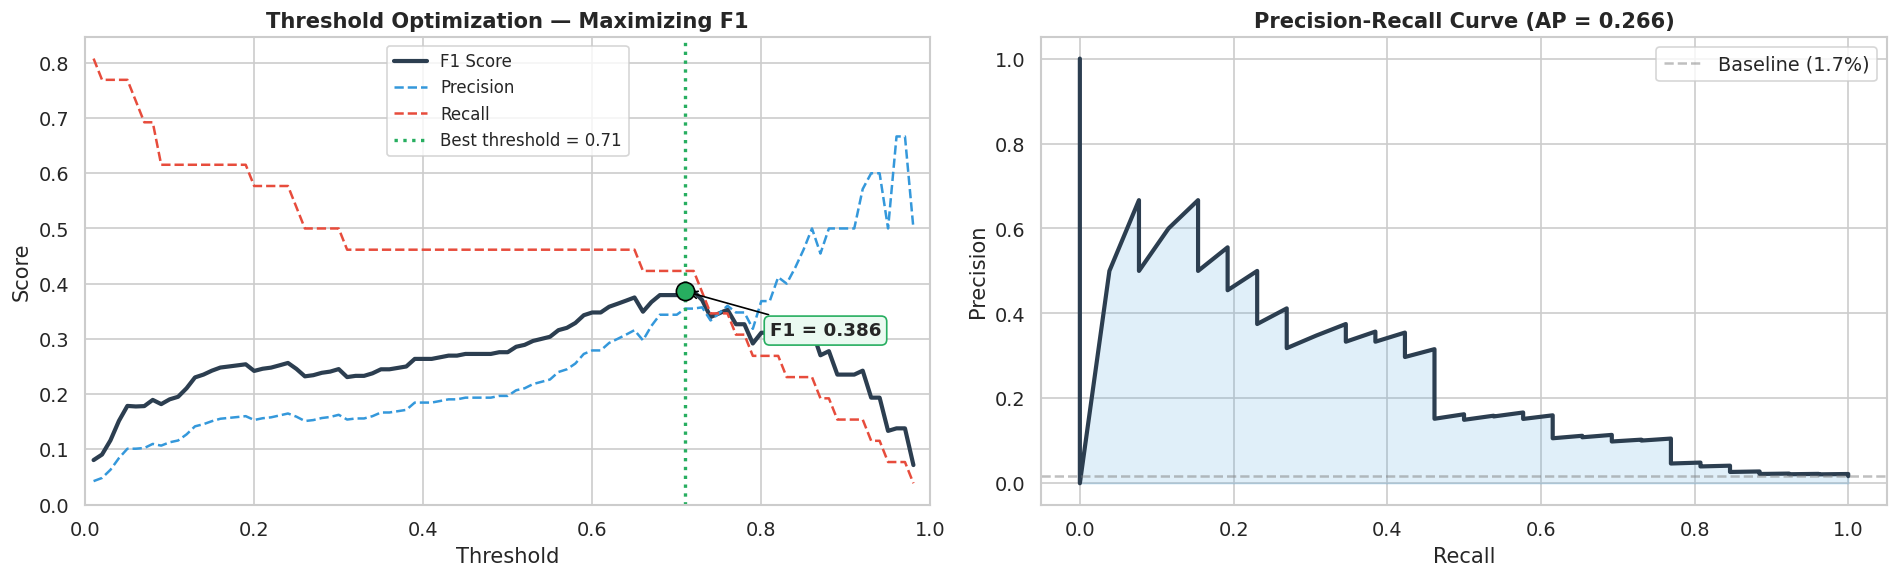

Optimal threshold: 0.71
F1: 0.3860  |  Precision: 0.3548  |  Recall: 0.4231


In [4]:
# ── Threshold Optimization ──
thresholds = np.arange(0.01, 0.99, 0.01)
f1s, precs, recs = [], [], []
for t in thresholds:
    yp = (y_proba >= t).astype(int)
    f1s.append(f1_score(y_test, yp, zero_division=0))
    precs.append(precision_score(y_test, yp, zero_division=0))
    recs.append(recall_score(y_test, yp, zero_division=0))

best_idx = np.argmax(f1s)
best_t = thresholds[best_idx]
best_f1 = f1s[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(thresholds, f1s, color='#2c3e50', lw=2.5, label='F1 Score')
ax.plot(thresholds, precs, color='#3498db', lw=1.5, ls='--', label='Precision')
ax.plot(thresholds, recs, color='#e74c3c', lw=1.5, ls='--', label='Recall')
ax.axvline(best_t, color='#27ae60', lw=2, ls=':', label=f'Best threshold = {best_t:.2f}')
ax.scatter([best_t], [best_f1], color='#27ae60', s=120, zorder=5, edgecolors='black')
ax.annotate(f'F1 = {best_f1:.3f}', xy=(best_t, best_f1),
            xytext=(best_t + 0.1, best_f1 - 0.08), fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black'),
            bbox=dict(boxstyle='round,pad=0.3', fc='#eafaf1', ec='#27ae60'))
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Optimization — Maximizing F1', fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 1)

precision_pr, recall_pr, _ = precision_recall_curve(y_test, y_proba)
ax2 = axes[1]
ax2.plot(recall_pr, precision_pr, color='#2c3e50', lw=2.5)
ax2.fill_between(recall_pr, precision_pr, alpha=0.15, color='#3498db')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title(f'Precision-Recall Curve (AP = {ap:.3f})', fontweight='bold')
ax2.axhline(y_test.mean(), color='gray', ls='--', alpha=0.5, label=f'Baseline ({y_test.mean():.1%})')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'Optimal threshold: {best_t:.2f}')
print(f'F1: {best_f1:.4f}  |  Precision: {precs[best_idx]:.4f}  |  Recall: {recs[best_idx]:.4f}')

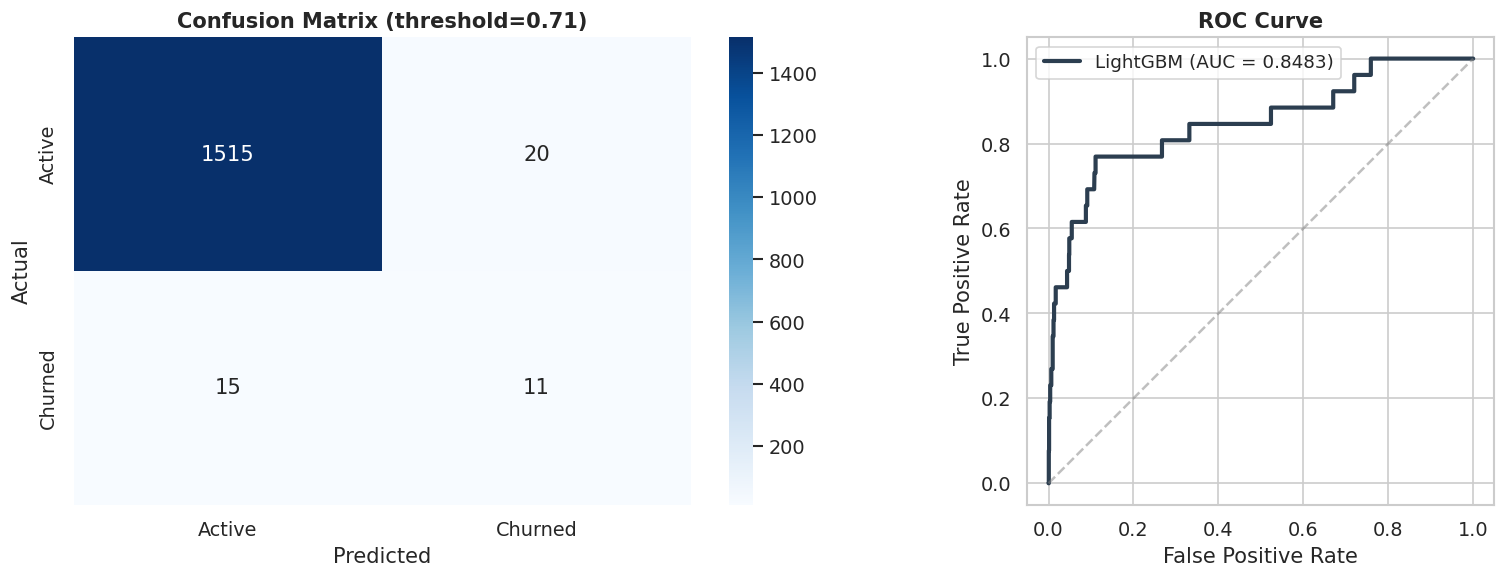

              precision    recall  f1-score   support

      Active       0.99      0.99      0.99      1535
     Churned       0.35      0.42      0.39        26

    accuracy                           0.98      1561
   macro avg       0.67      0.71      0.69      1561
weighted avg       0.98      0.98      0.98      1561



In [5]:
# ── Confusion Matrix & ROC ──
y_pred = (y_proba >= best_t).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Active', 'Churned'], yticklabels=['Active', 'Churned'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix (threshold={best_t:.2f})', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#2c3e50', lw=2.5, label=f'LightGBM (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', ls='--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

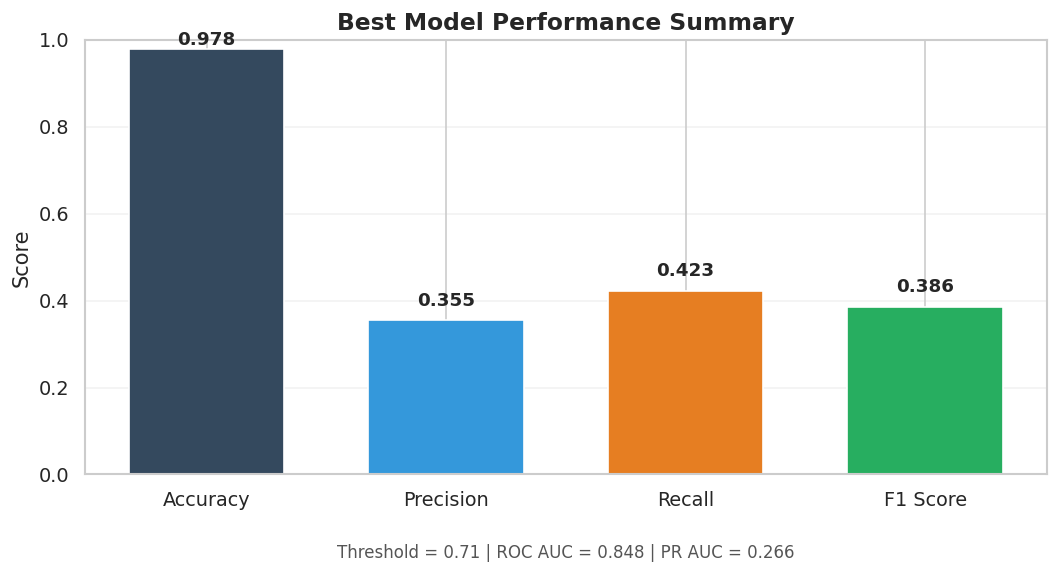

Accuracy     0.9776
Precision    0.3548
Recall       0.4231
F1 Score     0.3860


In [6]:
# ── Performance Summary ──
metric_values = pd.Series({
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'F1 Score': f1_score(y_test, y_pred, zero_division=0),
})

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#34495e', '#3498db', '#e67e22', '#27ae60']
bars = ax.bar(metric_values.index, metric_values.values, color=bar_colors, width=0.65)

ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Best Model Performance Summary', fontweight='bold', fontsize=14)
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)

for bar, value in zip(bars, metric_values.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        min(value + 0.025, 0.98),
        f'{value:.3f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

summary_text = f'Threshold = {best_t:.2f} | ROC AUC = {auc:.3f} | PR AUC = {ap:.3f}'
ax.text(0.5, -0.16, summary_text, transform=ax.transAxes,
        ha='center', va='top', fontsize=10, color='#555555')

plt.tight_layout()
plt.show()

print(metric_values.round(4).to_string())

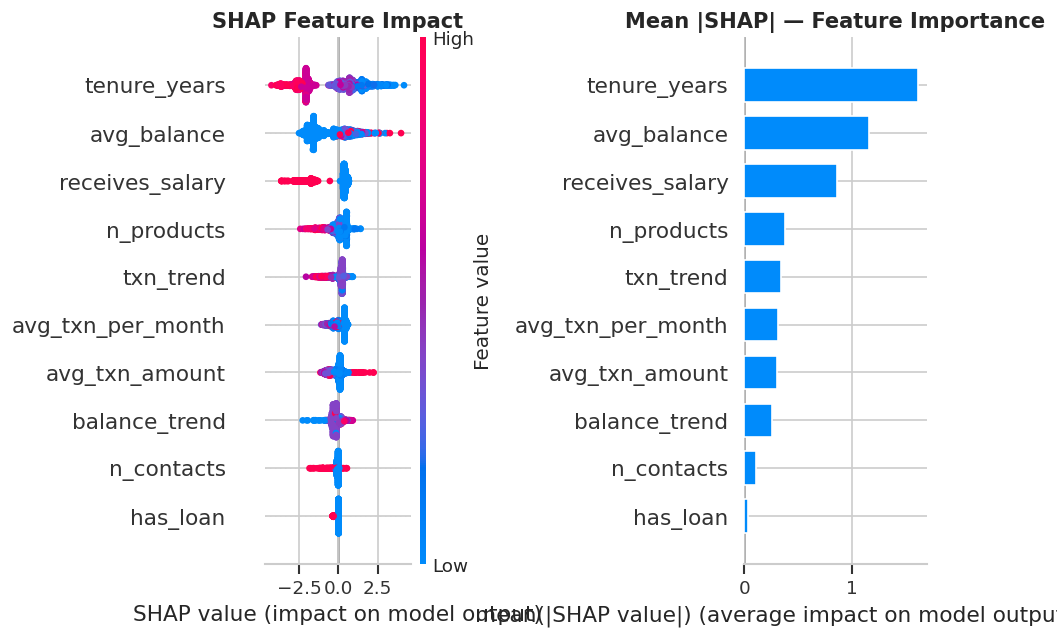

LightGBM native feature importance (gain):
          feature  importance
      avg_balance         381
     tenure_years         348
   avg_txn_amount         241
avg_txn_per_month         215
    balance_trend         211
        txn_trend         163
       n_contacts         159
       n_products         152
  receives_salary          41
         has_loan           3


In [7]:
# ── SHAP Feature Importance ──
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.summary_plot(sv, X_test, feature_names=FEATURES, show=False, max_display=len(FEATURES))
axes[0].set_title('SHAP Feature Impact', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(sv, X_test, feature_names=FEATURES, plot_type='bar',
                  show=False, max_display=len(FEATURES))
axes[1].set_title('Mean |SHAP| — Feature Importance', fontweight='bold')

plt.tight_layout()
plt.show()

fi = pd.DataFrame({
    'feature': FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print('LightGBM native feature importance (gain):')
print(fi.to_string(index=False))

Raw probability range: [0.0000, 0.9961]
Scaled risk score range: [0.0, 1.0]
Scaled threshold: 0.713 (raw: 0.710)


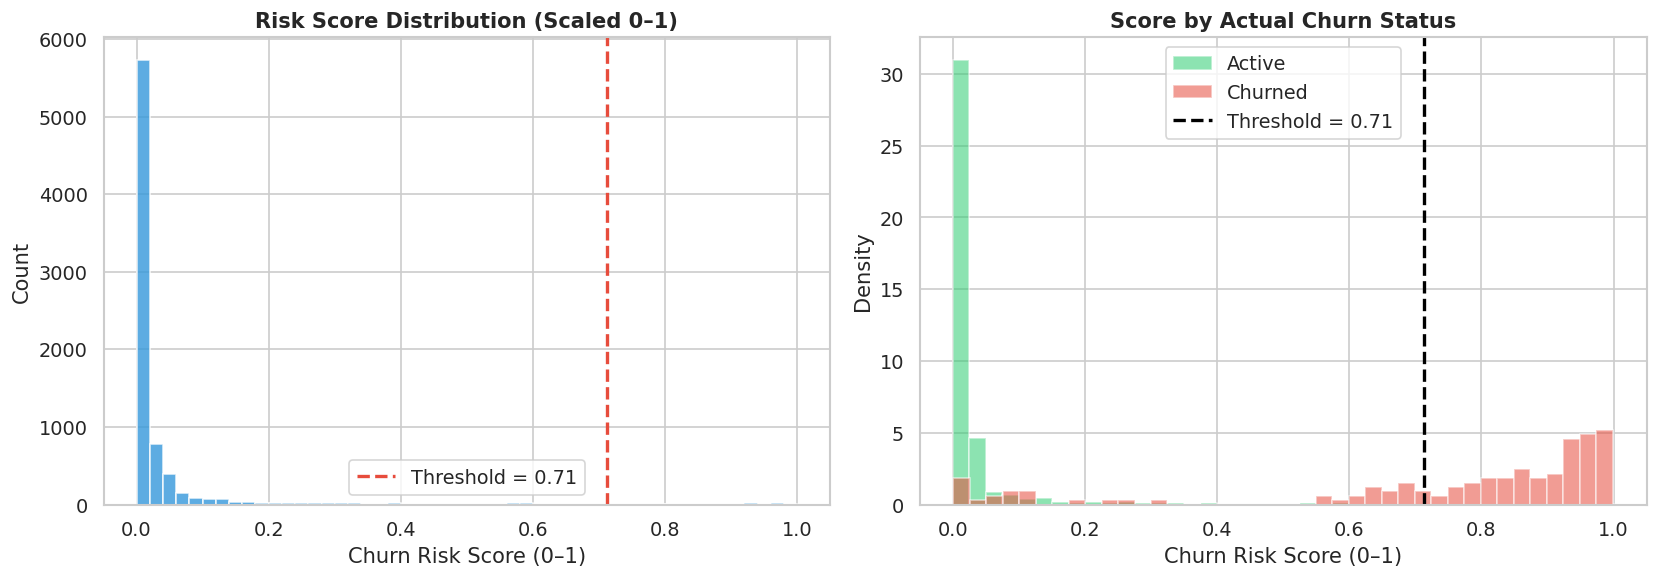

Saved: ../data/output/churn_risk_scores.csv
  High risk: 130 (1.7%)
  Low risk:  7,675 (98.3%)

Top 10 highest-risk customers:


,client_id,churn_risk_score,predicted_churn
0,JYD48Y7RR0J0,1.000000,1
1,AVN9LWG4PU9Y,0.998354,1
2,00Z3MS5XXZDA,0.997149,1
3,18OAPAUPBS9X,0.994901,1
4,3XIZ5V1ERJ8U,0.990076,1
5,NZKVBERD4FCN,0.987763,1
6,EAZ39CXN367X,0.987477,1
7,GQEQ5I7T3B0D,0.985666,1
8,C6B6DNP7GUMO,0.985267,1
9,83BR3JF54KS1,0.985152,1


In [8]:
# ── Risk Scores (scaled 0–1) ──
raw_proba = model.predict_proba(X)[:, 1]

p_min, p_max = raw_proba.min(), raw_proba.max()
risk_scaled = (raw_proba - p_min) / (p_max - p_min)
print(f'Raw probability range: [{p_min:.4f}, {p_max:.4f}]')
print(f'Scaled risk score range: [0.0, 1.0]')

scaled_threshold = (best_t - p_min) / (p_max - p_min)
scaled_threshold = np.clip(scaled_threshold, 0.0, 1.0)
print(f'Scaled threshold: {scaled_threshold:.3f} (raw: {best_t:.3f})')

risk = df[['client_id']].copy()
risk['churn_risk_score'] = risk_scaled
risk['predicted_churn'] = (risk_scaled >= scaled_threshold).astype(int)
risk = risk.sort_values('churn_risk_score', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(risk['churn_risk_score'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(scaled_threshold, color='#e74c3c', lw=2, ls='--',
                label=f'Threshold = {scaled_threshold:.2f}')
axes[0].set_xlabel('Churn Risk Score (0\u20131)')
axes[0].set_ylabel('Count')
axes[0].set_title('Risk Score Distribution (Scaled 0\u20131)', fontweight='bold')
axes[0].legend()

for val, label, color in [(0, 'Active', '#2ecc71'), (1, 'Churned', '#e74c3c')]:
    subset = risk_scaled[y == val]
    axes[1].hist(subset, bins=40, alpha=0.55, color=color, label=label, density=True)
axes[1].axvline(scaled_threshold, color='black', lw=2, ls='--',
                label=f'Threshold = {scaled_threshold:.2f}')
axes[1].set_xlabel('Churn Risk Score (0\u20131)')
axes[1].set_ylabel('Density')
axes[1].set_title('Score by Actual Churn Status', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

risk_path = OUTPUT / 'churn_risk_scores.csv'
risk.to_csv(risk_path, index=False)

n_high = (risk['predicted_churn'] == 1).sum()
n_low = len(risk) - n_high
print(f'Saved: {risk_path}')
print(f'  High risk: {n_high:,} ({n_high/len(risk):.1%})')
print(f'  Low risk:  {n_low:,} ({n_low/len(risk):.1%})')
print(f'\nTop 10 highest-risk customers:')
risk.head(10)